<a href="https://colab.research.google.com/github/bobroberts2639/Pangolin-Security-Consulting-Services-tutte-institute-acme3/blob/main/acme3_mapping__3_processes_as_bags_of_dlls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3 of 6 TutteInstitute/acm3-mapping

<div>
<img src="https://connoiter.com/images/tutte/king_tutte_on_colab.transparent_bg.png" align="left" width="200px"/>

Note: this is the fourth of the six notebooks TutteInstitute/acm3-mapping. The first one is identified as 0.

This notebook, [acme3-mapping__3_processes_as_bags_of_dlls.ipynb](https://github.com/Connoiter/king_tutte_datamap_codex/tree/main/by_repo/acme3-mapping/acme3-mapping__3_processes_as_bags_of_dlls.ipynb), is part of [the King Tutte Datamap Codex repo](https://github.com/Connoiter/king_tutte_datamap_codex), which contains a [Jupyter Book](https://jupyterbook.org/). The Jupyter notebooks in the King Tutte Datamap Codex run on Colab, and that fact is essentially the only value of this Codex work: curate and package pre-existing datamap example code and minimally modify the code to run out-of-the-box on Colab. As such, the King Tutte Datamap Codex Jupyter Book consists of King Tutte datamap pipelines that run on Google's Colab.
</div>
<br/>

## Pedigree

This notebook is simply a Colab-ified variant of [3 Processes as bags of DLLs.ipynb
](https://github.com/TutteInstitute/acme3-mapping/blob/main/3%20Processes%20as%20bags%20of%20DLLs.ipynb), which is part of the Tutte Institute's repo, [acme3-mapping](https://github.com/TutteInstitute/acme3-mapping).

## What this notebook does

<img src="https://user-images.githubusercontent.com/50601643/218871643-2d3af433-0923-4786-b5e5-24c6a72e803e.png" align="right" height="100px"/>

Lawrence Livermore National Laboratory (LLNL) has produced a tool, [Wintap](https://github.com/LLNL/Wintap), which is [MIT licensed](https://github.com/llnl/Wintap/blob/main/LICENSE). As part of that project, they currated some test data, as explained on [a LLNL website](https://gdo168.llnl.gov/). One of those datasets is known as [ACME 3](https://gdo168.llnl.gov/data/ACME3/). These six notebooks apply King Tutte pipelines to the ACME 3 dataset in order to demonstrate how they can be used to diagnose hacks of Windows networks.

In Notebook #0, the recorded commandlines of ACME 3 were tokenized. In Notebook #1 they were naively datamapped. This notebook refines the process with the goal "of this notebook: look at a vector space embedding of process instances as sets of code images" as mentioned below by the original author.

For the fullest explanation of these six notebooks, watch the 34 minute recording of a SciPy 2024 talk by [one of the authors of the original six notebooks](https://github.com/TutteInstitute/acme3-mapping/graphs/contributors), Benoit Hamelin of the Tutte Institute:

[![Vector space embeddings and data maps for cyber defense](https://img.youtube.com/vi/j1w4WHgtfDg/maxresdefault.jpg)](https://www.youtube.com/watch?v=j1w4WHgtfDg)

For more info, see [the King Tutte repo's acme3-mapping readme](https://github.com/Connoiter/king_tutte_datamap_codex/tree/main/by_repo/acme3-mapping).


For more info (including a long video explanation), see [the repo's acme3-mapping readme](https://github.com/Connoiter/king_tutte_datamap_codex/tree/main/by_repo/acme3-mapping).


# Embedding process instances as bags of code images

Observing patterns of similarity among complex telemetry datasets involves peering at it through _multiple lenses_.
The work of embedding command lines in [notebooks 1](1%20Command%20lines%20-%20-Bags%20of%20words.ipynb) [and 2](2%20Command%20lines%20-%20Wasserstein%20embedding.ipynb) yielded one such lense.
Here is another one.

Modern software is far from standalone:
most of its functionality is actually leveraged from operating system services and other routines lifted from _shared code libraries_.
On Windows, any file containing code getting loaded by a process (its own executable, as well as the libraries it relies on) is called a _code image_, or _image file_.
For a program to load a new code image raises an event on auditing systems that get captured by the host-based sensor,
and thus transfered to telemetry.

When trying to fathom the behaviour of a program,
an analyst will look at the code images it loads:
like Checkhov's guns,
a program has got to leverage certain APIs if it cares to bloat its memory space with all this code.
In many cases, this provides a rough idea of the purpose of the program.
Therefore, we can surmise that programs that depend on the similar sets of code images might serve similar purpoes.

---

**Goal of this notebook**:
look at a vector space embedding of process instances as sets of code images.

---

## Configure constants

In [ ]:
# Set this "CONSTANT" to wherever on Hugging Face the output Parquet files of Notebook #0 is.
# "connoiter/acme3-mapping" works as is because Connoiter has previously parked
# the data on Hugging Face.
REPO_ID_OF_DATA_ON_HUGGING_FACE = "connoiter/acme3-mapping-TEMP"

## Install Tutte Institute packages

The original TutteInstitute/acm3-mapping notebooks assume that various Tutte Institute tools get installed via `environment.yml` which is not the case on Colab. So to get this to work on Colab, Connoiter added in the following `pip install` commands.


In [ ]:
!pip install umap-learn
!pip install datamapplot
!pip install vectorizers
!pip install fast_hdbscan
!pip install glasbey

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.6/350.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.6 MB/s eta 0:00:00
  Created wheel for Pyqtree: filename=Pyqtree-1.0.0-py3-none-any.whl size=5969 sha256=9907b7691a352b6b42547971c0115179789455e77f26890d6e70f604c6696ada
  Stored in directory: /root/.cache/pip/wheels/86/02/24/506ac193949f48c8bec599b613d722bd64a83063a190b3bff7
Successfully built Pyqtree
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 1.4 MB/s eta 0:00:00


In [ ]:
import datamapplot as dmp
from fast_hdbscan import HDBSCAN
import glasbey
import numpy as np
import pandas as pd
import scipy.sparse
import shlex
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from tqdm.auto import trange
import umap
import vectorizers as vz
import vectorizers.transformers as vzt

## Download intermediate data from Hugging Face

The original Tutte Institute notebook assumes that files generated by earlier notebooks (#0 and #1) are sitting in the localhost file system. That is not the case on Colab (on Colab all notebooks are run on new runtimes; file system state is not persisted between notebooks as is the case with, say, Jupyter Lab), so Connoiter has been saving intermediate product files off to Hugging Face. Now we need to download those Parquet files to make the rest of Tutte's code run as-was.


In [ ]:
from huggingface_hub import hf_hub_download

def download_from_huggingface(repo_id, filename):
    hf_hub_download(
        repo_id=repo_id,
        local_dir=".",
        filename=filename
    )

download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "image_loads.parquet")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_iwt.npz")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_bagofwords.npz")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_labels_hovertext.parquet")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "color_map.json")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "process_filtered.parquet")

image_loads.parquet:   0%|          | 0.00/6.22M [00:00<?, ?B/s]

cmdlines_iwt.npz:   0%|          | 0.00/329k [00:00<?, ?B/s]

cmdlines_bagofwords.npz:   0%|          | 0.00/257k [00:00<?, ?B/s]

cmdlines_labels_hovertext.parquet:   0%|          | 0.00/135k [00:00<?, ?B/s]

color_map.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

process_filtered.parquet:   0%|          | 0.00/5.24M [00:00<?, ?B/s]

TODO: wire this up to a KTCodex URL.

In [notebook 0](0%20Gather%20and%20engineer%20dataset.ipynb#imageloads),
we filtered the image load events to the set of filtered processes.
We will identify each code image by the path to the file that contains it on disk.

In [ ]:
image_loads = pd.read_parquet("image_loads.parquet")
image_loads

,pid_hash,filename,timestamp
0,AD0DD8FE522C8245DB1FE6843542CE5D,c:\windows\system32\wermgr.exe,2023-11-05 00:02:30.978349+00:00
1,AD0DD8FE522C8245DB1FE6843542CE5D,c:\windows\system32\ntdll.dll,2023-11-05 00:02:30.978364+00:00
2,AD0DD8FE522C8245DB1FE6843542CE5D,c:\windows\system32\kernel32.dll,2023-11-05 00:02:30.979265+00:00
3,AD0DD8FE522C8245DB1FE6843542CE5D,c:\windows\system32\kernelbase.dll,2023-11-05 00:02:30.979419+00:00
4,AD0DD8FE522C8245DB1FE6843542CE5D,c:\windows\system32\msvcrt.dll,2023-11-05 00:02:30.980991+00:00
...,...,...,...
1621846,D2211D916C3414FDFBD2663BB9051C84,c:\windows\system32\npmproxy.dll,2023-11-20 23:55:23.410633+00:00
1621847,D2211D916C3414FDFBD2663BB9051C84,c:\windows\system32\wintypes.dll,2023-11-20 23:55:23.413362+00:00
1621848,D2211D916C3414FDFBD2663BB9051C84,c:\windows\system32\taskschd.dll,2023-11-20 23:55:23.418445+00:00
1621849,D2211D916C3414FDFBD2663BB9051C84,c:\windows\system32\sspicli.dll,2023-11-20 23:55:23.418901+00:00


We must now express each process instance as a sequence of code image paths.
When we have pivoted tabular information,
we can use `vectorizers.transformers.CategoricalColumnTransformer` for this purpose.

In [ ]:
%%time
images_x_process = vzt.CategoricalColumnTransformer("pid_hash", "filename").fit_transform(image_loads)
images_x_process

CPU times: user 2.77 s, sys: 95.9 ms, total: 2.87 s
Wall time: 6.19 s


,0
pid_hash,
0001A7D9420F65F0E8B07E78E1D26B45,[c:\program files (x86)\microsoft\edgeupdate\m...
000442B02967B85605AA0EAEC09B3C65,"[c:\windows\system32\svchost.exe, c:\windows\s..."
0004B89274C488D14B82AC4B82FCE8C1,"[c:\windows\system32\umpdc.dll, c:\windows\sys..."
000631F56921E5408C209847F5C08982,"[c:\windows\system32\umpdc.dll, c:\windows\sys..."
000633B71BF1319C229720F1407B06AB,[c:\windows\system32\windows.networking.connec...
...,...
FFF37EA8B2562643513B43C1AFE6631B,"[c:\windows\system32\mousocoreworker.exe, c:\w..."
FFF4C0540420379CED9EF8FBBF629BBD,"[c:\windows\system32\taskhostw.exe, c:\windows..."
FFFBEC447AE450B63B77772055BCC046,[c:\program files (x86)\microsoft\edgeupdate\m...


Interestingly, we seem to have many _less_ process instances represented in this manner than through command lines.
This is because the Windows auditing systems work on a best effort policy:
under load, such systems will not report all the events being generated,
for fear of using too much CPU time and storage space for auditing rather than for user computations.
Thus, we only get exposed to a subset of image load events.
We can expect our representation to be noisy because of that:
many of our process instances will be characterized only by a subset of their actual loaded images.
To wit: we have literally _zero_ image loads for nearly 100,000 process instances!

Now we have each process instance described as a sequence of tokens,
we build the counts matrix, and reweight it on the basis of information contributions.

In [ ]:
%%time
vz_tc = vz.NgramVectorizer().fit(images_x_process.tolist())
processes_tc = vz_tc._train_matrix.tocsr()
processes_tc

CPU times: user 14.2 s, sys: 394 ms, total: 14.6 s
Wall time: 21.4 s


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1621851 stored elements and shape (41346, 8322)>

In [ ]:
%%time
processes_iwt = vzt.InformationWeightTransformer().fit_transform(processes_tc)
processes_iwt

CPU times: user 2.03 s, sys: 16.1 ms, total: 2.05 s
Wall time: 1.81 s


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1621851 stored elements and shape (41346, 8322)>

In the present case, we could use the `vectorizers.TokenCooccurrenceVectorizer` to crunch the cooccurrence representation for code images.
However, it would be much too much work, as the relative position of code images in the sequence is irrelevant
(unlike tokens in a command line).
Instead, we can simply get the orderless cooccurrence matrix by folding the count matrix unto itself.

In [ ]:
%%time
sum_rows_iwt = np.array(np.sum(processes_iwt, axis=0)).squeeze()
images_cooc = scipy.sparse.diags(sum_rows_iwt) @ processes_iwt.T @ processes_iwt
images_cooc

CPU times: user 606 ms, sys: 19.7 ms, total: 625 ms
Wall time: 643 ms


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2986758 stored elements and shape (8322, 8322)>

8,000 dimensions is quite large, yielding heavy computations for Wasserstein embedding.
We get by perfectly fine with smaller vectors, with preservation of the _global_ similarity structure.

In [ ]:
%%time
images_svd = TruncatedSVD(n_components=512).fit_transform(images_cooc)
images_svd.shape

CPU times: user 22 s, sys: 923 ms, total: 22.9 s
Wall time: 19.3 s


(8322, 512)

Wasserstein embedding takes its usual few minutes.
Do crush some candy.

In [ ]:
%%time
processes_wass = vz.WassersteinVectorizer().fit_transform(processes_iwt, vectors=images_svd)

CPU times: user 7min 22s, sys: 21.1 s, total: 7min 43s
Wall time: 5min 34s


Now produce the 2D data map.

In [ ]:
%%time
processes_dmap = umap.UMAP(metric="cosine", unique=True, verbose=True).fit_transform(processes_wass)

UMAP(angular_rp_forest=True, metric='cosine', unique=True, verbose=True)
Unique=True -> Number of data points reduced from  41346  to  4641
Most common duplicate is 6  with a count of  2828
Wed Jul 15 04:03:01 2026 Construct fuzzy simplicial set
Wed Jul 15 04:03:01 2026 Finding Nearest Neighbors
Wed Jul 15 04:03:01 2026 Building RP forest with 8 trees
Wed Jul 15 04:03:06 2026 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	 4  /  12
	Stopping threshold met -- exiting after 4 iterations
Wed Jul 15 04:03:21 2026 Finished Nearest Neighbor Search
Wed Jul 15 04:03:27 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Jul 15 04:03:34 2026 Finished embedding
CPU times: user 36.8 s, sys: 876 ms, total: 37.7 s
Wall time: 34.7 s


Let's identify each point by the command line (hover text).

In [ ]:
metadata = images_x_process.rename("images").to_frame().merge(
    pd.read_parquet("process_filtered.parquet"),
    left_index=True,
    right_on="pid_hash",
    how="left"
).set_index("pid_hash")
assert (metadata.index == images_x_process.index).all()
hover_text = metadata["name"] + metadata["cmdline"].map(lambda x: '"'.join(x.split('"')[2:]))
hover_text

,0
pid_hash,
0001A7D9420F65F0E8B07E78E1D26B45,microsoftedgeupdate.exe /ua /installsource sch...
000442B02967B85605AA0EAEC09B3C65,svchost.exe -k netsvcs -p -s netsetupsvc
0004B89274C488D14B82AC4B82FCE8C1,svchost.exe -k netsvcs -p -s netsetupsvc
000631F56921E5408C209847F5C08982,svchost.exe -k netsvcs -p -s netsetupsvc
000633B71BF1319C229720F1407B06AB,mousocoreworker.exe -embedding
...,...
FFF37EA8B2562643513B43C1AFE6631B,mousocoreworker.exe -embedding
FFF4C0540420379CED9EF8FBBF629BBD,taskhostw.exe
FFFBEC447AE450B63B77772055BCC046,microsoftedgeupdate.exe /ua /installsource sch...


How to annotate the map?
We are characterizing each process instance by the code images it loads.
So a cluster of points is likely composed of process instances that load very similar sets of code images.
For each cluster, let's identify which 3 code images are most _distinguishing_ for the cluster with respect to all the rest.
The way to do that consists in computing the joint distribution of code image usage:
it will stand as our _null distribution_.
Then for the cluster, we calculate the distribution of its **local** code image usage;
we then identify which 3 code images for the cluster are used more frequently than the null distribution accounts for.

In [ ]:
clusters = HDBSCAN(min_cluster_size=10).fit_predict(processes_dmap)
num_clusters = np.unique(clusters).shape[0] - 1
num_clusters

465

In [ ]:
def normalized_distribution(M):
    S = M.mean(axis=0)
    return np.array(S).squeeze() / np.sum(S)


null_distrib = normalized_distribution(processes_iwt)
gt_lt = {True: ">", False: "<"}

K = 3
topics = {-1: "Unlabelled"}
for cluster in trange(num_clusters):
    distrib_cluster = normalized_distribution(processes_iwt[clusters == cluster])
    diff = np.abs(distrib_cluster - null_distrib)
    i_most_important = np.argsort(-diff)[:K]
    topic = "\n".join(gt_lt[distrib_cluster[i] > null_distrib[i]] + vz_tc.column_index_dictionary_[i].split('\\')[-1] for i in i_most_important)
    topics[cluster] = topic + "\u202D" * cluster if topic else "Unlabelled"

  0%|          | 0/465 [00:00<?, ?it/s]

The last line of the previous cell is a dirty trick to make force each cluster to have its very own label,
even if the label string collides with another cluster's.
We use the writing direction change Unicode code point,
a glyph-less code point,
to make the string stricly unique without changing its appearance in the plot.

<InteractiveFigure width=100% height=800>
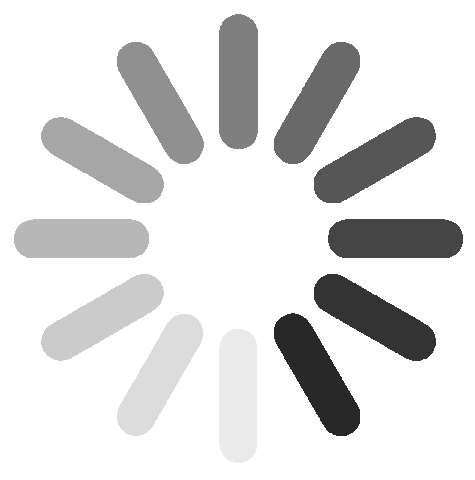

In [ ]:
dmp.create_interactive_plot(
    processes_dmap,
    [topics[c] for c in clusters],
    hover_text=list(hover_text),
    darkmode=False,
    enable_search=True,
    title="Process instances",
    sub_title="as distributions over a cloud of code image cooccurrence vectors",
)

This data map shows a very different type of variability than does command line embeddings.
Whereas the latter showed a large spread of embedding points for browsers,
under this lense,
they now pile up in a tiny cluster
(with respect to the 2D area),
thanks to browser processes always loading the same code images.
In contrast, general purpose programs such as `python.exe` and `mscorsvw.exe` show up all over the plot:
the APIs they source depend on the exact computation they are meant to support.